<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</center></font>
<center><font size=6>Evaluating Agentic AI Systems</center></font>

<center><p float="center">
  <img src="https://images.pexels.com/photos/6170458/pexels-photo-6170458.jpeg" width="640"/>
</p></center>

<center><font size=6>AI-powered Shipment Disruption Router
</center></font>

## **Problem Statement**

### Business Context


A global third-party logistics (3PL) provider manages end-to-end freight movements for large retail and manufacturing customers across **North America and Europe**, coordinating approximately **25,000 shipments per month** across road, ocean, and air transportation. The company operates as a mature, high-volume logistics operation, with regional control-tower teams responsible for monitoring shipment status, carrier performance, warehouse capacity, customs activity, and customer service-level agreements (SLAs).

Timely disruption management is critical because delays can result in missed delivery commitments, expedited transportation costs, inventory shortages, customer penalties, and additional operational workload. The company currently handles disruptions such as **severe weather, port congestion, customs holds, carrier failures, missed connections, and warehouse capacity constraints** through dispatcher-led review.

For each disruption, dispatchers manually review information from multiple operational sources, interpret operating policies, assess the impact on the shipment and customer SLA, and determine whether the shipment should be rerouted, held, or escalated. This process typically takes **2–4 hours per incident** and can produce inconsistent decisions across dispatchers handling similar situations. Limited visibility into the rationale behind individual decisions also makes operational reviews, SLA investigations, and compliance audits more difficult.

The process has become increasingly difficult to manage as shipment volumes and disruption frequency have grown. Dispatchers must rely on established procedures and individual experience while consolidating information across different operational systems and coordinating with carriers, warehouses, customs teams, and customers.

The current manual disruption-management process is too slow and inconsistent to support growing shipment volumes, resulting in delayed recovery decisions, avoidable SLA breaches, and limited decision traceability. The company has relied on manual dispatcher-led review and established operating procedures to manage disruptions, but this approach remains dependent on individual judgment and does not scale efficiently with increasing disruption volumes.

If the issue is not addressed, increasing shipment volumes and disruption frequency will continue to drive higher operational costs, SLA penalties, customer dissatisfaction, and control-tower workload.

### Objective

Over the next **6 months**, the company aims to improve the **speed, consistency, and traceability** of shipment-disruption decisions while maintaining appropriate human oversight for ambiguous or high-risk operational cases.

The company will target:
- Reduce average disruption decision time from **2–4 hours to less than 30 minutes**.
- Achieve at least **90% correct routing decisions** against validated operational ground truth.
- Reduce **disruption-related SLA breaches by 20%**.
- Reduce avoidable escalations while retaining human review for ambiguous, high-risk, or policy-sensitive cases.
- Maintain sufficient decision records for **operational reviews, SLA investigations, and compliance audits**.

### Data Description

| Column | Description |
|------|-------------|
| Order Id | Unique identifier for each test case or order used to simulate shipping scenarios. |
| Type | Payment or transaction type associated with the order (e.g., Debit). |
| Days for shipping (real) | Actual number of days taken to deliver the order. |
| Days for shipment (scheduled) | Planned or scheduled number of days allocated for shipment. |
| Delivery Status | Final delivery outcome such as on-time, late delivery, or canceled shipment. |
| Late_delivery_risk | Binary indicator (0 or 1) showing whether the order has a risk of late delivery. |
| Order Status | Current status of the order such as COMPLETE or CANCELED. |
| Shipping Mode | Mode of shipping used (e.g., Standard Class, Second Class, First Class). |
| Order Region | Geographic region where the order was placed. |
| Order City | City from which the order originated or was processed. |
| Order Country | Country where the order was placed. |
| Customer Segment | Customer category such as Consumer or Corporate. |
| Category Name | Product category associated with the order (e.g., Electronics, Books). |
| Sales | Total sales amount for the order item(s). |
| Order Item Quantity | Number of items included in the order. |
| delay_gap | Difference between actual shipping days and scheduled shipping days (real - scheduled). Positive values indicate delay, negative values indicate faster delivery. |
| decision_expected | Expected operational decision or action (e.g., monitor, reroute, expedite, escalate to human). |
| expected_policies | Policy IDs that should be triggered or applied for the given scenario. Multiple policies may be separated by `|`. |

## **Solution Architecture**

1. **Classifier Node**
   Classifies the shipment disruption, determines severity, and assigns a confidence score. Low-confidence cases are routed for escalation.

2. **Router Agent**
   Uses a ReAct-style loop to decide the required actions and select from three tools: **Policy Search**, **Decision Drafting**, and **Self-Validation**.

3. **Safety Check**
   Checks the agent’s final state and determines whether to deliver the decision, continue the agent loop, or escalate.

4. **Human Escalation**
   Ambiguous or high-risk cases, and cases that exceed validation retry limits, are paused for dispatcher review.


### Flow Diagram

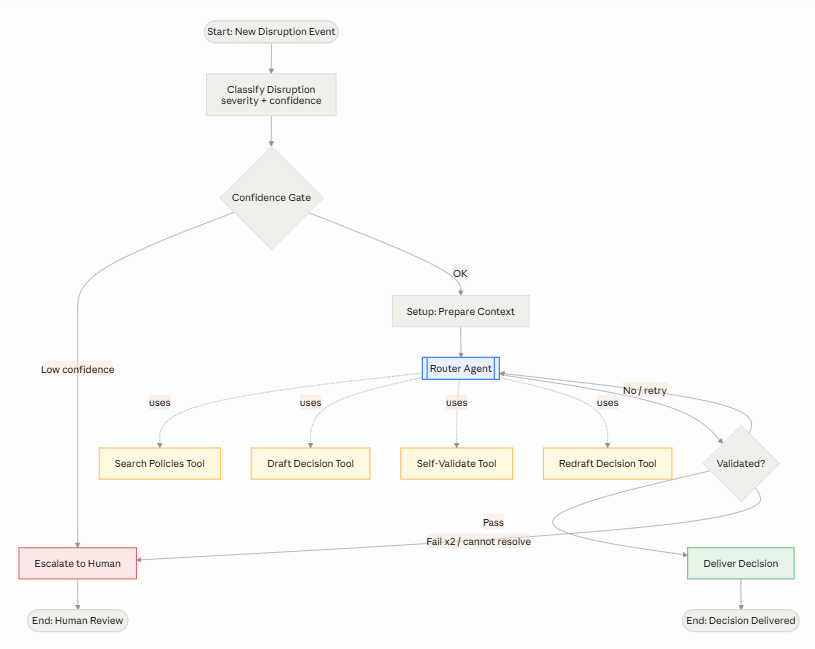

## **Installing and Importing Necessary Libraries and Dependencies**

In [ ]:
!pip install -q \
    langchain \
    langchain-openai \
    langgraph \
    langsmith \
    langchain-huggingface \
    langchain-chroma \
    sentence-transformers \
    pandas numpy \
    python-dotenv \
    tiktoken

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import os
import re
import json
import uuid
import statistics
from typing import List, Optional, Literal, TypedDict, Annotated, Dict, Any, Tuple
from datetime import datetime

import pandas as pd
import numpy as np
from pydantic import BaseModel, Field

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, AnyMessage
from langchain_openai import ChatOpenAI

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

from IPython.display import display, Image

## **LLM and Agent Observability Setup**

### LangSmith Setup

In an agentic workflow, agents and tools may run in sequence, passing state and intermediate results between them. As the workflow grows in complexity, it becomes challenging to understand:

- why a particular routing decision was made,
- which documents or chunks were retrieved,
- where an incorrect or unexpected output originated,

and more.

LangSmith provides observability for agentic AI workflows by logging:

- the end-to-end execution flow
- all tool and agent calls
- intermediate inputs and outputs
- key performance metrics

With LangSmith, one can debug errors, evaluate system behavior, and validate that a workflow is executing as intended. Without this level of tracing, diagnosing issues in complex agentic AI workflows becomes time-consuming and error-prone.

**How to obtain a LangSmith API Key?**

1. Visit: [https://smith.langchain.com](https://smith.langchain.com)  
2. Sign in and go to **Settings → API Keys**  
3. Generate a new API key  
4. Store this key securely (for example, in a `config.json` file or environment variables)

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name"
}
```

The API key enables tracing for the specific project workspace.

**Note**: You can define a unique project name in LangSmith for each case study, and all traces and agent executions will be tracked and organized under that specific project for structured monitoring and comparison.


### OpenAI API Setup

The credentials for OpenAI setup need to be stored in the same `config.json` file as the LangSmith credentials.

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name",
  "OPENAI_API_KEY": "your_openai_key",
  "OPENAI_API_BASE": "your_openai_base_url"
}

We load all OpenAI and LangSmith credentials from a secure `config.json` file and store them as environment variables.

In [ ]:
# Name of the configuration file that stores API keys and settings
file_name = 'config.json'

# Open the config.json file in read mode
with open(file_name, 'r') as file:

    # Load the JSON content from the file into a Python dictionary
    config = json.load(file)

    # Set the OpenAI API key as an environment variable
    # This allows libraries like OpenAI or LangChain to access the key securely
    os.environ['OPENAI_API_KEY'] = config.get("OPENAI_API_KEY")

    # Set the OpenAI base URL (used when calling OpenAI-compatible APIs or custom endpoints)
    os.environ['OPENAI_BASE_URL'] = config.get("OPENAI_API_BASE")

    # Enable LangSmith / LangChain tracing (used for debugging and monitoring LLM chains)
    os.environ['LANGCHAIN_TRACING_V2'] = config.get("LANGCHAIN_TRACING_V2")

    # Set the LangSmith API key for authentication with the LangSmith tracing platform
    os.environ['LANGCHAIN_API_KEY'] = config.get("LANGCHAIN_API_KEY")

    # Define the LangSmith project name where traces and logs will be recorded
    os.environ['LANGCHAIN_PROJECT'] = config.get("LANGCHAIN_PROJECT")

We use two LLMs with distinct responsibilities:

- **gpt-4o-mini** for classifier, decision drafting, and the router agent loop (cost-efficient)
- **gpt-4o** for independent validation (stronger reasoning for adversarial rubric evaluation)

In [ ]:
llm_fast = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_validator = ChatOpenAI(model="gpt-4o", temperature=0)

Initialize LangSmith client to enable tracing and evaluation of the agentic workflow, with automatic fallback if configuration is unavailable.

In [ ]:
from langsmith import traceable, Client
from langsmith.evaluation import evaluate

# Initialize LangSmith client
try:
    langsmith_client = Client()
    LANGSMITH_ENABLED = True
    print("LangSmith tracing enabled")
except:
    LANGSMITH_ENABLED = False
    print("LangSmith not configured - tracing disabled")

LangSmith tracing enabled


## **Test Case & Policy Data Setup**

### Load Test Cases

In [ ]:
df = pd.read_csv('test_cases_curated.csv', encoding='ISO-8859-1')

View the first 5 rows of the dataset.

In [ ]:
df.head(5)

,Order Id,Type,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Order Status,Shipping Mode,Order Region,Order City,Order Country,Customer Segment,Category Name,Sales,Order Item Quantity,delay_gap,decision_expected,expected_policies
0,TC001,DEBIT,4,4,Shipping on time,0,COMPLETE,Standard Class,West of USA,Los Angeles,United States,Consumer,Water Sports,199.99,2,0,monitor,POL-004
1,TC002,DEBIT,6,2,Late delivery,1,COMPLETE,Second Class,Northern Europe,London,United Kingdom,Corporate,Men's Footwear,129.99,1,4,reroute,POL-002
2,TC003,DEBIT,2,4,Shipping canceled,0,CANCELED,Standard Class,Central America,Panama City,Panama,Corporate,Fishing,399.98,3,-2,escalate_human,POL-003
3,TC004,DEBIT,6,4,Late delivery,1,COMPLETE,First Class,Eastern Asia,Tokyo,Japan,Corporate,Electronics,3500.00,1,2,expedite,POL-002|POL-006
4,TC005,DEBIT,5,4,Late delivery,1,COMPLETE,Standard Class,Canada,Toronto,Canada,Consumer,Books,75.00,1,1,monitor,POL-004


### Build Policy Vector Store

Builds a Chroma vector store from the logistics policy rulebook for semantic search.

In [ ]:
def build_vectorstore(file_path: str) -> Chroma:
    # Load the logistics policy rulebook
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Split the policy text into smaller, overlapping chunks for retrieval
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100,
        separators=["\n\nPOL-", "\n\n", "\n", " ", ""],
    )
    chunks = splitter.split_text(text)

    # Create documents and associate each chunk with its policy ID
    docs, current_id = [], None
    for chunk in chunks:
        m = re.search(r"POL-\d{3}", chunk)
        if m:
            current_id = m.group()

        docs.append(
            Document(
                page_content=chunk,
                metadata={"policy_id": current_id or "GENERAL"}
            )
        )

    # Generate embeddings for each policy chunk
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

    # Store the embedded policy chunks in Chroma using cosine similarity
    vs = Chroma.from_documents(
        documents=docs,
        embedding=embeddings,
        collection_name="logistics_policies",
        collection_metadata={"hnsw:space": "cosine"}
    )

    print(f"Vector store built: {len(docs)} chunks")
    return vs


# Build the vector store from the logistics policy rulebook
vectorstore = build_vectorstore("logistics_policy_rulebook.txt")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vector store built: 15 chunks


## **Multi-Agent System Architecture**

In this section, we will build the core components of the multi-agent logistics decision system:

* **Workflow State:** Define the shared session state and workflow state used to maintain and pass information across the different components of the workflow.
* **Classifier:** Build the component that classifies disruption events and assigns severity and confidence.
* **Router Agent Components:** Build the policy retrieval, decision drafting, validation, and redrafting components used by the Router Agent.
* **Router Agent:** Configure the Router Agent to select and execute the appropriate tools based on the current state and validation feedback.
* **Delivery:** Define the path for delivering a validated routing decision.
* **Escalation:** Define the path for cases that require human intervention.

### Session State

Defines the state shared across workflow nodes, including event data, agent outputs, decisions, validation results, and escalation details.

In [ ]:
class WorkflowState(TypedDict, total=False):
    event_data: Dict[str, Any]
    classification: Dict[str, Any]
    messages: Annotated[List[AnyMessage], add_messages]
    agent_iterations: int
    routing_decision: Dict[str, Any]
    validation_result: Dict[str, Any]
    policy_bank: Dict[str, Dict[str, Any]]
    final_decision: str
    requires_human: bool
    escalation_reason: str
    reasoning_trail: List[str]

Maintains mutable data used by the agents and tools during a workflow run, including retrieved policies, decisions, and validation status.

In [ ]:
class Session:
    def __init__(self):
        self.reset()

    def reset(self):
        self.event: Dict[str, Any] = {}
        self.classification: Dict[str, Any] = {}
        self.policy_bank: Dict[str, Dict[str, Any]] = {}
        self.search_count: int = 0
        self.decision: Dict[str, Any] = {}
        self.validation: Dict[str, Any] = {}
        self.validation_fail_count: int = 0

session = Session()

### Classifier Node

Defines the structured output for the classifier, including disruption type, severity, confidence, and reasoning.

In [ ]:
class DisruptionClassification(BaseModel):
    disruption_types: List[str] = Field(description="All applicable: weather, carrier_failure, capacity_breach, customs_hold, standard_delay")
    primary_disruption_type: str
    severity: str = Field(description="low, medium, high, or critical")
    severity_score: float
    confidence: float
    reasoning: str

Creates the classification prompt and constrains the LLM to return the defined structured output.

In [ ]:
classify_prompt = ChatPromptTemplate.from_messages([
    ("system", """Classify a logistics disruption event.

Return:
1. disruption_types (multi-label): weather, carrier_failure, capacity_breach, customs_hold, standard_delay
2. primary_disruption_type (single most significant)
3. severity: low / medium / high / critical
4. confidence 0-1

Severity guide:
- LOW: < 2 days delay, standard mode, low value
- MEDIUM: 2-4 days delay, some SLA pressure
- HIGH: 4-6 days, premium mode, corporate customer
- CRITICAL: > 6 days, canceled, high value + corporate"""),
    ("human", """Order {order_id} | {delivery_status} | {shipping_mode}
Scheduled {days_scheduled}d, actual {days_real}d, delay {delay_gap}d
Late risk: {late_risk} | {customer_segment} | ${sales} | {category} | {region}""")
])

classify_chain = classify_prompt | llm_fast.with_structured_output(DisruptionClassification)

Sets the minimum confidence required for a classification to proceed through the workflow.

In [ ]:
CONFIDENCE_THRESHOLD = 0.6

Runs the classifier on the event data and stores the classification and reasoning trail in the workflow state.

In [ ]:
def classify_node(state: WorkflowState) -> dict:
    result = classify_chain.invoke(state["event_data"])
    c = result.model_dump()
    trail = state.get("reasoning_trail", []) + [
        f"Classify: {c['primary_disruption_type']} severity={c['severity']} conf={c['confidence']:.2f}"
    ]
    return {"classification": c, "reasoning_trail": trail}

### Confidence Gate

Deterministic if/else. Low-confidence classifications skip the router agent entirely.

In [ ]:
def confidence_gate(state: WorkflowState) -> Literal["setup", "escalate"]:
    if state["classification"]["confidence"] < CONFIDENCE_THRESHOLD:
        return "escalate"
    return "setup"

### Deliver Node

Delivers the validated routing decision and passes the final workflow results to the next stage.

In [ ]:
def deliver_node(state: WorkflowState) -> dict:
    decision = session.decision.get("decision", "monitor")
    trail = state.get("reasoning_trail", []) + [f"Delivered: {decision}"]
    return {
        "final_decision": decision,
        "requires_human": decision == "escalate_human",
        "routing_decision": session.decision,
        "validation_result": session.validation,
        "policy_bank": dict(session.policy_bank),
        "reasoning_trail": trail,
    }

### Escalate Node

Escalates cases to human review when classifier confidence is low, validation repeatedly fails, or the Router Agent cannot produce a validated decision.

In [ ]:
def escalate_node(state: WorkflowState) -> dict:
    # Retrieve the event details from the workflow state
    event = state["event_data"]

    # Get classifier confidence; default to 1.0 if confidence is unavailable
    conf = state.get("classification", {}).get("confidence", 1.0)

    # Determine why the incident needs human intervention
    if conf < CONFIDENCE_THRESHOLD:
        reason = f"Low classifier confidence ({conf:.2f})"

    elif session.validation_fail_count >= MAX_VALIDATION_FAILURES:
        reason = f"Validation failed {session.validation_fail_count} times"

    else:
        reason = "Router agent could not produce a validated decision"

    # Pause the workflow and wait for human intervention
    # Execution resumes only after the interrupt is resolved
    interrupt({
        "reason": reason,
        "order_id": event["order_id"],
        "segment": event["customer_segment"],
        "value": event["sales"],
        "status": event["delivery_status"],
        "delay": event["delay_gap"],
    })

    # Add the escalation reason to the reasoning trail
    trail = state.get("reasoning_trail", []) + [f"Escalated: {reason}"]

    # Return the updated state after escalation
    return {
        "final_decision": "escalate_human",
        "requires_human": True,
        "escalation_reason": reason,
        "routing_decision": session.decision or {},
        "validation_result": session.validation or {},
        "policy_bank": dict(session.policy_bank),
        "reasoning_trail": trail,
    }

### Router Agent Tools

In this section, we will build and configure the components that enable the Router Agent to retrieve policies, generate routing decisions, validate them, and revise them based on validation feedback.

* **Policy Retrieval:** Search the policy vector store and maintain the retrieved policies.
* **Decision Drafting:** Generate a structured routing decision using the event details and retrieved policies.
* **Decision Validation:** Independently evaluate the decision for citation entailment, completeness, schema correctness, and logical consistency.
* **Decision Redrafting:** Revise failed decisions using the validator's feedback while working with the existing policy set.


#### Policy Tool

Semantic search over the policy vector store. Agent picks query and k. Max 3 calls per run; results deduplicated into `session.policy_bank`.

In [ ]:
MAX_SEARCHES = 3

@tool
@traceable(name="search_policies_tool")
def search_policies_tool(query: str, k: int = 5) -> str:
    """
    Search the policy vector store.
    Provide a query string and k (3-10).
    Maximum 3 searches are allowed per run.
    Results are added to the shared policy bank.
    """

    # Stop searching once the maximum number of searches is reached
    if session.search_count >= MAX_SEARCHES:
        return json.dumps({
            "status": "SEARCH_LIMIT_REACHED",
            "policies_in_bank": list(session.policy_bank.keys()),
        })

    # Perform semantic similarity search against the policy vector store
    results = vectorstore.similarity_search_with_score(query, k=k)

    # Track the number of searches performed in this run
    session.search_count += 1

    # Store IDs of policies that are newly added to the policy bank
    new_ids = []

    # Process each retrieved policy chunk
    for doc, score in results:
        pid = doc.metadata.get("policy_id", "UNKNOWN")

        # If the policy already exists, add new content to it
        if pid in session.policy_bank:
            if doc.page_content.strip() not in session.policy_bank[pid]["content"]:
                session.policy_bank[pid]["content"] += "\n\n" + doc.page_content
                session.policy_bank[pid]["chunks"] += 1

        # Otherwise, add the policy as a new entry
        else:
            session.policy_bank[pid] = {
                "content": doc.page_content,
                "score": score,
                "chunks": 1
            }
            new_ids.append(pid)

    # Return the search status and policies currently available
    # in the shared policy bank
    return json.dumps({
        "status": "SUCCESS",
        "new_policies": new_ids,
        "all_policies": list(session.policy_bank.keys()),
    })

#### Drafting Tool

Defines the structured output for a routing decision, including the recommended action, action plan, policy citations, routing details, confidence, and reasoning.

In [ ]:
class RoutingDecision(BaseModel):
    decision: str = Field(description="reroute, hold, expedite, escalate_human, or monitor")
    action_plan: List[str]
    policy_citations: List[str]
    geographic_routing: Optional[str] = None
    confidence: float
    reasoning: str

Defines the priority rules that guide the routing decision, with the first matching rule taking precedence.

In [ ]:
PRIORITY_RULES = """PRIORITY RULES (apply in order, first match wins):
1. Shipping canceled -> escalate_human (policy POL-003)
2. Value > $3,000 AND late risk -> expedite (policy POL-002)
3. Electronics AND delay > 2 days -> reroute (policy POL-006)
4. Delay within SLA tolerance -> monitor (policy POL-004)
   Standard: 3d | Second: 2d | First: 1d | Same Day: 0d
5. Delay 2-5 days, reroute available -> reroute (policy POL-002)
6. Delay < 2 days, within tolerance -> monitor (policy POL-004)"""

Creates the prompt for generating a policy-grounded routing decision and enforces the required output structure and citation format.

In [ ]:
draft_prompt = ChatPromptTemplate.from_messages([
    ("system", """Draft a routing decision. Every decision must cite retrieved policy IDs.

Decisions: reroute, hold, expedite, escalate_human, monitor

Priority Rules:

""" + PRIORITY_RULES + """


CITATION FORMAT:
policy_citations must contain ONLY bare policy IDs like "POL-002" or "POL-006".
Never include descriptive text, labels, or parenthetical notes in the citation strings themselves.

ACTION PLAN REQUIREMENTS:
- Read the full text of every retrieved policy you cite, not just its ID.
- If a cited policy specifies a concrete requirement (a handling instruction, a timeline,
  a notification step, a routing constraint), include that specific requirement as its own
  step in action_plan. Do not summarize it away.
-
- Each action_plan step should be concrete and specific to this event (mention the order ID,
  region, or category where relevant), not a generic placeholder like "monitor the situation".
- If a cited policy has no specific procedural requirement beyond the decision itself, it is
  fine to omit extra steps for it - do not invent requirements the policy text does not state."""),
    ("human", """Classification: {disruption_types} | severity: {severity}
Event: Order {order_id} | {delivery_status} | {shipping_mode} | delay {delay_gap}d
{customer_segment} | ${sales} | {category} | {region}

Policies:
{policies}""")
])

draft_chain = draft_prompt | llm_fast.with_structured_output(RoutingDecision)

Generates a routing decision from the retrieved policies and stores the structured decision in the shared session.

In [ ]:
@tool
@traceable(name="draft_decision_tool")
def draft_decision_tool() -> str:
    """Draft a routing decision from the retrieved policies. Call after searching."""
    if not session.policy_bank:
        return json.dumps({"status": "NO_POLICIES", "message": "Call search_policies_tool first"})

    policies = "\n".join(f"{pid}: {d['content'][:300]}" for pid, d in session.policy_bank.items())

    result = draft_chain.invoke({
        "disruption_types": ", ".join(session.classification["disruption_types"]),
        "severity": session.classification["severity"],
        "order_id": session.event["order_id"],
        "delivery_status": session.event["delivery_status"],
        "shipping_mode": session.event["shipping_mode"],
        "delay_gap": session.event["delay_gap"],
        "customer_segment": session.event["customer_segment"],
        "sales": session.event["sales"],
        "category": session.event["category"],
        "region": session.event["region"],
        "policies": policies,
    })

    session.decision = result.model_dump()
    return json.dumps({"status": "SUCCESS", "decision": session.decision})

#### Validation Tool

The routing decision is evaluated using a defined validation rubric:

* **Citation Entailment (40%)**: Checks whether the cited policies actually support the decision.
* **Completeness (20%)**: Checks whether all required fields contain sufficient and concrete details.
* **Schema Correctness (10%)**: Checks whether the decision follows the required types and formats.
* **Logical Consistency (30%)**: Checks whether the decision aligns with the event's severity, delay, value, category, and applicable rules.

**Feedback-Driven Validation:** When a dimension fails, the validator provides specific feedback and a concrete remediation. It also recommends the next action, such as re-searching for missing policy coverage, redrafting the decision, escalating the case, or accepting the decision.


Defines the structured output for evaluating the routing decision across multiple validation dimensions.

In [ ]:
class ValidationDimension(BaseModel):
    dimension: str
    score: float
    feedback: str
    remediation: str = Field(description="Concrete action if score < 0.6, empty if passed")

class ValidationResult(BaseModel):
    dimensions: List[ValidationDimension]
    overall_score: float
    issues_found: List[str]
    recommended_next_action: str = Field(description="re-search / redraft / escalate / accept")
    reasoning: str

Sets the minimum scores required for each validation dimension and the overall validation result to pass.

In [ ]:
DIMENSION_THRESHOLD = 0.6
OVERALL_THRESHOLD = 0.7

Creates an independent validation prompt that evaluates the decision against the priority rules and retrieved policies.

In [ ]:
validate_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an adversarial logistics decision auditor. Find flaws, not confirmations.

Priority Rules:
""" + PRIORITY_RULES + """

Score each dimension 0-1:
1. CITATION ENTAILMENT (weight 0.4): Do the cited policies actually support this decision,
   per the priority rules above?
2. COMPLETENESS (weight 0.2): All fields present with concrete detail?
3. SCHEMA CORRECTNESS (weight 0.1): Valid decision type, confidence 0-1, POL-XXX format?
4. LOGICAL CONSISTENCY (weight 0.3): Does the decision match the priority rule that applies
   to this event's severity, delay, value, category, and risk flags?

SCOPE (STRICT):
- Judge ONLY against the priority rules above and the fields actually present in the decision.
- Do NOT require details, precautions, or handling steps that are not stated in the priority
  rules or the retrieved policy text. If the decision matches the correct priority rule, that
  is sufficient for logical_consistency.

For any dimension < 0.6, provide a SPECIFIC remediation:
Good: "Search for 'SLA tolerance Standard Class' to find POL-004"
Bad: "Improve the citations"

recommended_next_action:
- "re-search: <reason>" if missing policy coverage
- "redraft: <reason>" if policies OK but decision weak
- "escalate: <reason>" if fundamental mismatch
- "accept" if all pass

Be strict, but only against the rules above."""),
    ("human", """Decision: {decision}

Event: Order {order_id} | {delivery_status} | {shipping_mode} | delay {delay_gap}d
{customer_segment} | ${sales} | {category} | {region} | severity: {severity}

Policies:
{policies}""")
])

validate_chain = validate_prompt | llm_validator.with_structured_output(ValidationResult)




Validates the routing decision, identifies issues, and provides remediation or the next action when validation fails.

In [ ]:
@tool
@traceable(name="self_validate_tool")
def self_validate_tool() -> str:
    """Validate the current decision. Returns pass/fail with per-dimension remediation."""

    # Check whether a decision has been generated before starting validation
    if not session.decision:
        return json.dumps({
            "status": "NO_DECISION",
            "recommended_next_action": "redraft"
        })

    # Pre-check citations to ensure every cited policy exists
    # in the retrieved policy bank
    cited = session.decision.get("policy_citations", [])
    bank_ids = set(session.policy_bank.keys())
    hallucinated = [p for p in cited if p not in bank_ids]

    # Fail immediately if the decision contains policies
    # that were not retrieved from the policy bank
    if hallucinated:
        session.validation_fail_count += 1

        session.validation = {
            "validation_passed": False,
            "overall_score": 0.0,
            "issues": [
                f"HALLUCINATED CITATIONS: {hallucinated} not in {list(bank_ids)}"
            ],
            "recommended_next_action":
                "redraft: remove hallucinated citations, use only retrieved policies",
        }

        return json.dumps({
            "status": "FAIL",
            "fail_count": session.validation_fail_count,
            **session.validation,
        })

    # Prepare the retrieved policies as context for the validator
    policies = "\n".join(
        f"{pid}: {d['content'][:300]}"
        for pid, d in session.policy_bank.items()
    )

    # Run the validator against the decision, event details,
    # classification, and retrieved policy evidence
    result = validate_chain.invoke({
        "decision": json.dumps(session.decision, indent=2),
        "order_id": session.event["order_id"],
        "delivery_status": session.event["delivery_status"],
        "shipping_mode": session.event["shipping_mode"],
        "delay_gap": session.event["delay_gap"],
        "customer_segment": session.event["customer_segment"],
        "sales": session.event["sales"],
        "category": session.event["category"],
        "region": session.event["region"],
        "severity": session.classification["severity"],
        "policies": policies,
    })

    # A decision passes only when every dimension meets the
    # minimum threshold and the overall score meets its threshold
    all_pass = all(
        d.score >= DIMENSION_THRESHOLD
        for d in result.dimensions
    )

    passed = (
        all_pass
        and result.overall_score >= OVERALL_THRESHOLD
    )

    # Track validation failures for retry/escalation handling
    if not passed:
        session.validation_fail_count += 1

    # Collect general validation issues and dimension-level feedback
    issues = list(result.issues_found)
    remediation = []

    for d in result.dimensions:
        # Add feedback for dimensions that failed the threshold
        if d.score < DIMENSION_THRESHOLD:
            issues.append(
                f"{d.dimension} {d.score:.2f}: {d.feedback}"
            )

            # Store suggested remediation for the failed dimension
            if d.remediation:
                remediation.append(
                    f"[{d.dimension}] {d.remediation}"
                )

    # Accept the decision if validation passes;
    # otherwise follow the validator's recommended next action
    next_action = (
        "accept"
        if passed
        else result.recommended_next_action
    )

    # Store the complete validation result in shared session state
    session.validation = {
        "validation_passed": passed,
        "overall_score": result.overall_score,
        "dimensions": [d.model_dump() for d in result.dimensions],
        "issues": issues,
        "remediation": remediation,
        "recommended_next_action": next_action,
    }

    # Return the validation outcome for the agent/workflow
    return json.dumps({
        "status": "PASS" if passed else "FAIL",
        "fail_count": session.validation_fail_count,
        **session.validation,
    })

#### Redrafting Tool

Defines the instructions for revising a failed routing decision using validator feedback and the existing retrieved policies.

In [ ]:
redraft_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are revising a routing decision that FAILED validation.

The retrieved policies are FIXED. Your job is to fix the DECISION based on the validator's
feedback, not to search for more policies.

STRICT RULES:
- Use only the policies already in the bank
- Address every issue the validator raised
- Cite policies that actually exist in the bank
- If a citation was flagged as hallucinated: remove or replace it with a real policy
- policy_citations must contain ONLY bare policy IDs like "POL-002", never labels or descriptions
- If completeness or grounding was flagged: check the actual retrieved policy text for cited
  IDs and make sure any concrete requirement it states is reflected in action_plan
- If the ONLY issue was citation formatting, keep the same decision, action_plan, and reasoning;
  just correct the citations

""" + PRIORITY_RULES),
    ("human", """Previous decision that FAILED:
{previous_decision}

Validator issues:
{issues}

Validator remediation:
{remediation}

Retrieved policies (unchanged):
{policies}

Event: Order {order_id} | {delivery_status} | {shipping_mode} | delay {delay_gap}d
{customer_segment} | ${sales} | {category} | {region}

Produce a revised RoutingDecision that addresses ALL issues.""")
])

Creates the redrafting chain that generates a revised structured routing decision.

In [ ]:
redraft_chain = redraft_prompt | llm_fast.with_structured_output(RoutingDecision)

Revises the failed decision using validation feedback without retrieving new policies, then updates the shared session.

In [ ]:

@tool
@traceable(name="redraft_decision_tool")
def redraft_decision_tool() -> str:
    """Revise the decision using validator feedback. Same policies, no new search.
    Call after self_validate_tool returns FAIL with recommended_next_action='redraft'."""
    if not session.decision:
        return json.dumps({"status": "NO_DECISION", "message": "Draft first before redrafting"})
    if not session.validation:
        return json.dumps({"status": "NOTHING_TO_REDRAFT", "message": "No prior validation feedback"})

    policies = "\n".join(f"{pid}: {d['content'][:300]}" for pid, d in session.policy_bank.items())

    result = redraft_chain.invoke({
        "previous_decision": json.dumps(session.decision, indent=2),
        "issues": "\n".join(f"- {i}" for i in session.validation.get("issues", [])) or "(none)",
        "remediation": "\n".join(f"- {r}" for r in session.validation.get("remediation", [])) or "(none)",
        "policies": policies,
        "order_id": session.event["order_id"],
        "delivery_status": session.event["delivery_status"],
        "shipping_mode": session.event["shipping_mode"],
        "delay_gap": session.event["delay_gap"],
        "customer_segment": session.event["customer_segment"],
        "sales": session.event["sales"],
        "category": session.event["category"],
        "region": session.event["region"],
    })

    session.decision = result.model_dump()
    return json.dumps({"status": "SUCCESS", "decision": session.decision})

### Router Agent

The Router Agent coordinates the decision-making workflow by using the available tools and responding to their outputs.

- Selects the appropriate tool based on the current workflow state.
- Searches for relevant policies before drafting a decision.
- Validates the drafted decision before completion.
- Uses validation feedback to re-search or redraft when required.
- Stops the workflow when validation passes or an escalation condition is reached.

Configures the Router Agent with its available tools and limits for iterations and validation failures.

In [ ]:
ROUTER_TOOLS = [search_policies_tool, draft_decision_tool, redraft_decision_tool, self_validate_tool]
router_llm = llm_fast.bind_tools(ROUTER_TOOLS)

MAX_ITERATIONS = 8
MAX_VALIDATION_FAILURES = 2

Defines the system prompt that guides the Router Agent's tool usage, workflow, validation, and escalation behavior.

In [ ]:
ROUTER_SYSTEM = """You are a Router Agent for logistics disruption decisions.

Tools:
- search_policies_tool(query, k): search policies. Pick query and k (3-10). Max 3 calls.
- draft_decision_tool(): produce the FIRST draft from retrieved policies.
- redraft_decision_tool(): revise a FAILED draft using validator feedback. Same policies.
- self_validate_tool(): validate the current draft. MANDATORY.

WORKFLOW:
1. Search for relevant policies.
2. Draft a decision with draft_decision_tool.
3. Validate with self_validate_tool.
4. If FAIL, read the validator's recommended_next_action:
   - "re-search: <reason>" -> call search_policies_tool with the suggested query
   - "redraft: <reason>"   -> call redraft_decision_tool (uses same policies + feedback)
   - "escalate: <reason>"  -> stop; system auto-escalates
5. Validate again after redraft or re-search.
6. If PASS: reply with plain text starting 'DONE'. Do NOT call any more tools.

RULES:
- Max 2 validation attempts. After 2 failures the system auto-escalates.
- Always call self_validate_tool before finishing.
- Do NOT call draft_decision_tool twice; use redraft_decision_tool for the second attempt."""


Resets the session and prepares the disruption event and classification as context for the Router Agent.

In [ ]:
def setup_node(state: WorkflowState) -> dict:
    """Reset the session and prepare initial messages for the agent."""
    session.reset()
    session.event = state["event_data"]
    session.classification = state["classification"]

    e, c = session.event, session.classification
    context = (
        f"DISRUPTION EVENT:\n"
        f"Order {e['order_id']} | {e['delivery_status']} | {e['shipping_mode']}\n"
        f"Delay: {e['delay_gap']}d | Late risk: {e['late_risk']} | {e['customer_segment']}\n"
        f"Value: ${e['sales']} | {e['category']} | {e['region']}\n\n"
        f"CLASSIFICATION: {', '.join(c['disruption_types'])} | "
        f"Primary: {c['primary_disruption_type']}\n"
        f"Severity: {c['severity']} ({c['severity_score']}) | Confidence: {c['confidence']}\n\n"
        f"Begin: search, draft, validate. Follow the validator's feedback."
    )

    return {
        "messages": [SystemMessage(content=ROUTER_SYSTEM), HumanMessage(content=context)],
        "agent_iterations": 0,
    }


Invokes the Router Agent to determine the next tool to call or whether to proceed toward completion.

In [ ]:
def agent_node(state: WorkflowState) -> dict:
    """Invoke the tool-bound LLM to pick the next tool or finish."""
    response = router_llm.invoke(state["messages"])
    return {
        "messages": [response],
        "agent_iterations": state.get("agent_iterations", 0) + 1,
    }

#### Loop control and safety check

The workflow uses deterministic controls to prevent unnecessary iterations and ensure that validation is completed before delivery.

Determines whether the workflow should execute tools or move to the safety check based on validation status and iteration limits.

In [ ]:
def agent_should_continue(state: WorkflowState) -> Literal["tools", "check"]:
    """Route to tools if agent called them, else to safety check.
    Force-exit deterministically if validation resolved or cap hit."""

    if session.validation.get("validation_passed"):
        return "check"
    if session.validation_fail_count >= MAX_VALIDATION_FAILURES:
        return "check"
    if state.get("agent_iterations", 0) >= MAX_ITERATIONS:
        return "check"

    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        return "tools"
    return "check"

Ensures the decision has been validated before allowing the workflow to proceed to delivery or escalation.

In [ ]:
def safety_check(state: WorkflowState) -> dict:
    """Nudge the agent if validation was skipped. Otherwise pass through."""
    # If validation failed 2x or passed, no more nudging - exit path decides
    if session.validation_fail_count >= MAX_VALIDATION_FAILURES:
        return {"messages": []}
    if session.validation.get("validation_passed"):
        return {"messages": []}

    # Check if self_validate_tool was called at all
    called = set()
    for msg in state["messages"]:
        if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
            for tc in msg.tool_calls:
                called.add(tc["name"])

    if "self_validate_tool" not in called:
        return {"messages": [HumanMessage(content=(
            "You did not call self_validate_tool. This is MANDATORY. Please validate now."
        ))]}

    return {"messages": []}

Determines whether to continue with the Router Agent, deliver the decision, or escalate the case for human review.

In [ ]:
def after_check_route(state: WorkflowState) -> Literal["agent", "deliver", "escalate"]:
    """Decide final destination after safety check."""
    last = state["messages"][-1]
    if isinstance(last, HumanMessage) and "MANDATORY" in last.content:
        return "agent"

    if session.validation_fail_count >= MAX_VALIDATION_FAILURES:
        return "escalate"
    if session.validation.get("validation_passed"):
        return "deliver"
    if session.decision and session.validation.get("overall_score", 0) >= 0.6:
        return "deliver"
    return "escalate"

## **Multi-Agent System Workflow**

Builds the LangGraph workflow by connecting the classifier, Router Agent, tools, safety checks, delivery, and escalation nodes, then compiles it with memory.

In [ ]:
tool_node = ToolNode(ROUTER_TOOLS)

workflow = StateGraph(WorkflowState)
workflow.add_node("classify", classify_node)
workflow.add_node("setup", setup_node)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)
workflow.add_node("check", safety_check)
workflow.add_node("deliver", deliver_node)
workflow.add_node("escalate", escalate_node)

workflow.add_edge(START, "classify")
workflow.add_conditional_edges("classify", confidence_gate, {"setup": "setup", "escalate": "escalate"})
workflow.add_edge("setup", "agent")
workflow.add_conditional_edges("agent", agent_should_continue, {"tools": "tools", "check": "check"})
workflow.add_edge("tools", "agent")
workflow.add_conditional_edges("check", after_check_route, {
    "agent": "agent", "deliver": "deliver", "escalate": "escalate",
})
workflow.add_edge("deliver", END)
workflow.add_edge("escalate", END)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)
print("Workflow compiled.")

Workflow compiled.


**Workflow Visualization**

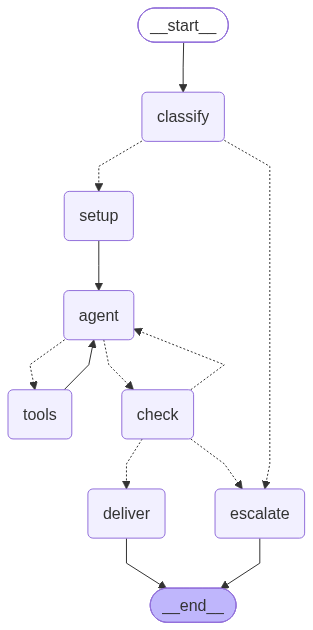

In [ ]:
Image(app.get_graph().draw_mermaid_png())

## **Evaluation Metrics**

Defines the structured output for evaluating the quality of the decision reasoning.

In [ ]:
class ReasoningEvaluation(BaseModel):
    logical_soundness: float
    policy_alignment: float
    completeness: float
    clarity: float
    overall_quality: float
    justification: str

Creates the evaluation prompt and chain used to assess reasoning quality across defined dimensions.

In [ ]:
judge_prompt = ChatPromptTemplate.from_messages([
    ("system", "Evaluate reasoning quality in logistics decisions. Score 0-1 on logical_soundness, policy_alignment, completeness, clarity, overall_quality."),
    ("human", "Context: {context}\nDecision: {decision} (conf {confidence})\nReasoning: {reasoning}\nCitations: {citations}\nAction plan: {plan}")
])

judge_chain = judge_prompt | llm_validator.with_structured_output(ReasoningEvaluation)

Evaluates the reasoning behind the routing decision and returns its overall quality score.

In [ ]:
def evaluate_reasoning(state: Dict[str, Any]) -> float:
    routing = state.get("routing_decision", {})
    if not routing:
        return 0.0
    try:
        result = judge_chain.invoke({
            "context": f"severity={state.get('classification', {}).get('severity', '')} delay={state['event_data']['delay_gap']}d",
            "decision": routing.get("decision", ""),
            "confidence": routing.get("confidence", 0),
            "reasoning": routing.get("reasoning", "")[:300],
            "citations": ", ".join(routing.get("policy_citations", [])),
            "plan": "; ".join(routing.get("action_plan", [])[:3]),
        })
        return result.overall_quality
    except Exception:
        return 0.0


Checks whether the workflow produced a final decision.

In [ ]:
def evaluate_task_completion(state: Dict[str, Any]) -> bool:
    return bool(state.get("final_decision"))

Compares the final decision produced by the workflow with the expected decision.

In [ ]:
def evaluate_decision_accuracy(state: Dict[str, Any], expected: str) -> bool:
    return state.get("final_decision", "") == expected

Measures whether the expected policies were retrieved into the policy bank.

In [ ]:
def evaluate_tool_accuracy(state: Dict[str, Any], expected_policies: str) -> float:
    bank = state.get("policy_bank", {})
    expected = expected_policies.split("|") if isinstance(expected_policies, str) else expected_policies
    if not expected:
        return 1.0
    return sum(1 for p in expected if p in bank) / len(expected)

## **Test Cases**

### Test Cases

In [ ]:
def prepare_event_data(row: pd.Series) -> Dict[str, Any]:
    delay = int(row["Days for shipping (real)"]) - int(row["Days for shipment (scheduled)"])
    return {
        "order_id": str(row["Order Id"]),
        "delivery_status": row["Delivery Status"],
        "shipping_mode": row["Shipping Mode"],
        "days_scheduled": int(row["Days for shipment (scheduled)"]),
        "days_real": int(row["Days for shipping (real)"]),
        "delay_gap": delay,
        "late_risk": int(row["Late_delivery_risk"]),
        "customer_segment": row["Customer Segment"],
        "sales": float(row["Sales"]),
        "category": row["Category Name"],
        "region": row["Order Region"],
        "city": row["Order City"],
            }

In [ ]:
CASE_LABELS = {
    "TC001": "On-Time Monitoring",
    "TC002": "Standard Reroute (Corporate Late Delivery)",
    "TC003": "Critical Escalation (Canceled Shipment)",
    "TC004": "High-Value Expedite (Electronics)",
    "TC005": "Minor Delay Hold",
}

test_cases = [(CASE_LABELS.get(row["Order Id"], row["Order Id"]), row) for _, row in df.iterrows()]

for label, _ in test_cases:
    print(f"  - {label}")

  - On-Time Monitoring
  - Standard Reroute (Corporate Late Delivery)
  - Critical Escalation (Canceled Shipment)
  - High-Value Expedite (Electronics)
  - Minor Delay Hold


### Test Runner

Displays the progress and key outputs from each node as the workflow executes.

In [ ]:
def _print_step(node: str, state: Dict[str, Any]):
    """Print a single workflow step with detail appropriate to the node."""

    # Display classification details produced by the classifier
    if node == "classify":
        c = state.get("classification", {})
        print(
            f"  [classify] primary={c.get('primary_disruption_type')} "
            f"severity={c.get('severity')} "
            f"conf={c.get('confidence', 0):.2f}"
        )

    # Confirm that the workflow session has been initialized
    elif node == "setup":
        print("  [setup] session initialized")

    # Display agent activity, including tool calls or final responses
    elif node == "agent":
        msgs = state.get("messages", [])

        if msgs:
            m = msgs[-1]

            # Show which tools the agent decided to call
            if getattr(m, "tool_calls", None):
                for tc in m.tool_calls:
                    args = json.dumps(
                        tc.get("args", {}),
                        default=str
                    )[:80]

                    print(
                        f"  [agent -> tool] "
                        f"{tc['name']}({args})"
                    )

            # Show the agent's final response when no tool is called
            else:
                content = (
                    (m.content or "")
                    .strip()[:120]
                    .replace("\n", " ")
                )
                print(f"  [agent -> DONE] {content}")

    # Display the result returned by each tool execution
    elif node == "tools":
        for m in state.get("messages", []):

            # Skip messages that are not tool messages
            if not hasattr(m, "name"):
                continue

            try:
                # Parse the tool's JSON response
                payload = json.loads(m.content)
                status = payload.get("status", "?")

                # Show retrieved policies from the policy search tool
                if m.name == "search_policies_tool":
                    extra = (
                        f" new={payload.get('new_policies', [])} "
                        f"all={payload.get('all_policies', [])}"
                    )

                # Show the decision and policy citations from the draft tool
                elif m.name == "draft_decision_tool":
                    d = payload.get("decision", {})
                    extra = (
                        f" decision={d.get('decision', '?')} "
                        f"citations={d.get('policy_citations', [])}"
                        if isinstance(d, dict)
                        else ""
                    )

                # Show validation score, failures, next action,
                # and remediation suggestions
                elif m.name == "self_validate_tool":
                    score = payload.get("overall_score", 0)
                    fails = payload.get("fail_count", 0)
                    nxt = payload.get("recommended_next_action", "")

                    extra = (
                        f" score={score:.2f} "
                        f"fails={fails} "
                        f"next={nxt}"
                    )

                    # Display up to two remediation suggestions
                    rem = payload.get("remediation", [])
                    if rem:
                        for r in rem[:2]:
                            extra += (
                                f"\n    remediation: {r[:100]}"
                            )

                # Show the updated decision after a redraft
                elif m.name == "redraft_decision_tool":
                    d = payload.get("decision", {})
                    extra = (
                        f" decision={d.get('decision', '?')} "
                        f"citations={d.get('policy_citations', [])}"
                        if isinstance(d, dict)
                        else ""
                    )

                else:
                    # No additional details for other tools
                    extra = ""

                print(
                    f"  [tool {m.name}] "
                    f"{status}{extra}"
                )

            # Handle tool responses that cannot be parsed as JSON
            except Exception:
                print(
                    f"  [tool {m.name}] "
                    f"(unparsed)"
                )

    # Indicate that the workflow reached the routing/check stage
    elif node == "check":
        print("  [check]")

    # Display the final decision when the workflow delivers the result
    elif node == "deliver":
        print(
            f"  [deliver] "
            f"final={state.get('final_decision', '?')}"
        )

    # Display the final decision and reason when human escalation occurs
    elif node == "escalate":
        print(
            f"  [escalate] "
            f"final={state.get('final_decision', '?')} "
            f"reason={state.get('escalation_reason', '?')}"
        )

Runs an individual test case through the workflow, displays the execution details, and evaluates the final result.

In [ ]:
def run_test_case(test_case: Tuple[str, pd.Series], app) -> Dict[str, Any]:
    # Extract the test case label and input data
    label, row = test_case

    # Display the test case details and expected outcome
    print("=" * 72)
    print(f"TEST: {label}")
    print(
        f"Expected: decision={row['decision_expected']} | "
        f"policies={row['expected_policies']}"
    )
    print("-" * 72)

    # Build the initial workflow state from the test case
    initial = {
        "event_data": prepare_event_data(row),
        "reasoning_trail": [],
        "messages": [],
    }

    # Create a unique thread ID so each test case has an isolated state
    thread_id = f"test_{row['Order Id']}_{uuid.uuid4().hex[:6]}"
    config = {"configurable": {"thread_id": thread_id}}

    # Run the workflow and print each node's execution state
    for step in app.stream(initial, config):
        for node, state in step.items():
            _print_step(node, state)

    # If the workflow is paused for human intervention,
    # simulate dispatcher approval and resume execution
    if app.get_state(config).next:
        print("  [auto-resume] simulating dispatcher approval...")
        for step in app.stream(
            Command(resume={"action": "approve"}),
            config
        ):
            for node, state in step.items():
                _print_step(node, state)

    # Retrieve the final workflow state after execution completes
    result = app.get_state(config).values

    # Display the policies retrieved during the workflow
    bank = result.get("policy_bank", {})
    if bank:
        print(f"\n  Retrieved policies: {list(bank.keys())}")

    # Display the router's decision, confidence, citations, and reasoning
    routing = result.get("routing_decision", {})
    if routing:
        print(f"\n  Routing Decision:")
        print(f"    decision: {routing.get('decision')}")
        print(
            f"    confidence: "
            f"{routing.get('confidence', 0):.2f}"
        )
        print(
            f"    citations: "
            f"{routing.get('policy_citations', [])}"
        )

        # Limit displayed reasoning to keep the test output concise
        r = routing.get("reasoning", "")[:200]
        if r:
            print(f"    reasoning: {r}")

    # Display validator results and individual dimension scores
    validation = result.get("validation_result", {})
    if validation:
        print(
            f"\n  Validation: "
            f"passed={validation.get('validation_passed')} "
            f"score={validation.get('overall_score', 0):.2f}"
        )

        for d in validation.get("dimensions", []):
            print(
                f"    {d['dimension']}: "
                f"{d['score']:.2f}"
            )

    # Evaluate the workflow across the defined evaluation metrics
    task_ok = evaluate_task_completion(result)
    decision_ok = evaluate_decision_accuracy(
        result,
        row["decision_expected"]
    )
    tool_acc = evaluate_tool_accuracy(
        result,
        row["expected_policies"]
    )
    reasoning_score = evaluate_reasoning(result)

    # Display the evaluation results for this test case
    print(f"\n  Evaluation:")
    print(
        f"    Task Complete:     "
        f"{'PASS' if task_ok else 'FAIL'}"
    )
    print(
        f"    Decision Accuracy: "
        f"{'PASS' if decision_ok else 'FAIL'} "
        f"(AI Decision={result.get('final_decision')})"
    )
    print(f"    Tool Accuracy:     {tool_acc:.0%}")
    print(f"    Reasoning Quality: {reasoning_score:.0%}")
    print("=" * 72 + "\n")

    # Return structured results for aggregate evaluation
    return {
        "label": label,
        "expected": row["decision_expected"],
        "actual": result.get("final_decision"),
        "task_complete": task_ok,
        "decision_correct": decision_ok,
        "tool_accuracy": tool_acc,
        "reasoning": reasoning_score,
        "escalated": result.get("requires_human", False),
        "confidence": result.get("classification", {}).get(
            "confidence", 0
        ),
    }

### Run All Tests

In [ ]:
TEST_RUN_HISTORY = []

#### Test 1: On-Time Monitoring

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(test_cases[0], app))

TEST: On-Time Monitoring
Expected: decision=monitor | policies=POL-004
------------------------------------------------------------------------
  [classify] primary=standard_delay severity=low conf=0.90
  [setup] session initialized
  [agent -> tool] search_policies_tool({"query": "standard delay logistics", "k": 5})
  [tool search_policies_tool] SUCCESS new=['POL-006', 'POL-002', 'POL-004', 'POL-001'] all=['POL-006', 'POL-002', 'POL-004', 'POL-001']
  [agent -> tool] draft_decision_tool({})
  [tool draft_decision_tool] SUCCESS decision=monitor citations=['POL-004']
  [agent -> tool] self_validate_tool({})
  [tool self_validate_tool] PASS score=0.94 fails=0 next=accept
  [agent -> DONE] DONE
  [check]
  [deliver] final=monitor

  Retrieved policies: ['POL-006', 'POL-002', 'POL-004', 'POL-001']

  Routing Decision:
    decision: monitor
    confidence: 0.90
    citations: ['POL-004']
    reasoning: The order TC001 is currently on time with a delay of 0 days, which falls within the SLA t

**Observation**

- The case followed the expected path, with the decision appropriately grounded in the applicable policy.


#### Test 2: Standard Reroute (Corporate Late Delivery)

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(test_cases[1], app))

TEST: Standard Reroute (Corporate Late Delivery)
Expected: decision=reroute | policies=POL-002
------------------------------------------------------------------------
  [classify] primary=standard_delay severity=high conf=0.90
  [setup] session initialized
  [agent -> tool] search_policies_tool({"query": "logistics disruption policies late delivery", "k": 5})
  [tool search_policies_tool] SUCCESS new=['POL-006', 'POL-002', 'POL-003', 'GENERAL', 'POL-001'] all=['POL-006', 'POL-002', 'POL-003', 'GENERAL', 'POL-001']
  [agent -> tool] draft_decision_tool({})
  [tool draft_decision_tool] SUCCESS decision=reroute citations=['POL-002', 'POL-006']
  [agent -> tool] self_validate_tool({})
  [tool self_validate_tool] FAIL score=0.68 fails=1 next=redraft: Correct the policy citation and ensure all relevant fields are complete
    remediation: [CITATION ENTAILMENT] Search for 'delay 2-5 days, reroute available' to find POL-002.
  [agent -> tool] redraft_decision_tool({})
  [tool redraft_decision

**Observation**

- The case correctly triggered a reroute based on the delay threshold, though reasoning completeness can be improved.


#### Test 3: Critical Escalation (Canceled Shipment)

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(test_cases[2], app))

TEST: Critical Escalation (Canceled Shipment)
Expected: decision=escalate_human | policies=POL-003
------------------------------------------------------------------------
  [classify] primary=standard_delay severity=low conf=0.90
  [setup] session initialized
  [agent -> tool] search_policies_tool({"query": "logistics disruption standard delay", "k": 5})
  [tool search_policies_tool] SUCCESS new=['POL-006', 'POL-001', 'POL-002', 'POL-003', 'POL-004'] all=['POL-006', 'POL-001', 'POL-002', 'POL-003', 'POL-004']
  [agent -> tool] draft_decision_tool({})
  [tool draft_decision_tool] SUCCESS decision=escalate_human citations=['POL-003']
  [agent -> tool] self_validate_tool({})
  [tool self_validate_tool] PASS score=0.94 fails=0 next=accept
  [agent -> DONE] DONE
  [check]
  [deliver] final=escalate_human

  Retrieved policies: ['POL-006', 'POL-001', 'POL-002', 'POL-003', 'POL-004']

  Routing Decision:
    decision: escalate_human
    confidence: 0.90
    citations: ['POL-003']
    reasoni

**Observation**

- The critical cancellation was correctly escalated to human review, though the reasoning quality indicates scope for stronger justification.


#### Test 4: High-Value Expedite (Electronics)

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(test_cases[3], app))

TEST: High-Value Expedite (Electronics)
Expected: decision=expedite | policies=POL-002|POL-006
------------------------------------------------------------------------
  [classify] primary=standard_delay severity=medium conf=0.90
  [setup] session initialized
  [agent -> tool] search_policies_tool({"query": "standard delay logistics", "k": 5})
  [tool search_policies_tool] SUCCESS new=['POL-006', 'POL-002', 'POL-004', 'POL-001'] all=['POL-006', 'POL-002', 'POL-004', 'POL-001']
  [agent -> tool] draft_decision_tool({})
  [tool draft_decision_tool] SUCCESS decision=reroute citations=['POL-006', 'POL-002']
  [agent -> tool] self_validate_tool({})
  [tool self_validate_tool] PASS score=0.92 fails=0 next=accept
  [agent -> DONE] DONE
  [check]
  [deliver] final=reroute

  Retrieved policies: ['POL-006', 'POL-002', 'POL-004', 'POL-001']

  Routing Decision:
    decision: reroute
    confidence: 0.90
    citations: ['POL-006', 'POL-002']
    reasoning: The order is categorized as electronics 

**Observation**

- The validator detected repeated policy conflicts and correctly triggered human escalation after two failed validations, but the case still missed the expected **expedite** decision.


#### Test 5: Minor Delay Hold

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(test_cases[4], app))

TEST: Minor Delay Hold
Expected: decision=monitor | policies=POL-004
------------------------------------------------------------------------
  [classify] primary=standard_delay severity=low conf=0.90
  [setup] session initialized
  [agent -> tool] search_policies_tool({"query": "standard delay logistics", "k": 5})
  [tool search_policies_tool] SUCCESS new=['POL-006', 'POL-002', 'POL-004', 'POL-001'] all=['POL-006', 'POL-002', 'POL-004', 'POL-001']
  [agent -> tool] draft_decision_tool({})
  [tool draft_decision_tool] SUCCESS decision=monitor citations=['POL-004']
  [agent -> tool] self_validate_tool({})
  [tool self_validate_tool] PASS score=0.94 fails=0 next=accept
  [agent -> DONE] DONE
  [check]
  [deliver] final=monitor

  Retrieved policies: ['POL-006', 'POL-002', 'POL-004', 'POL-001']

  Routing Decision:
    decision: monitor
    confidence: 0.90
    citations: ['POL-004']
    reasoning: The delay for Order TC005 is only 1 day, which is within the SLA tolerance for standard cla

**Observation**

- The case correctly handled a minor delay with a policy-grounded monitor decision, achieving **full validation and reasoning scores**.


### Summary Metrics

In [ ]:
def show_summary():
    if not TEST_RUN_HISTORY:
        print("No tests executed yet.")
        return
    summary = pd.DataFrame(TEST_RUN_HISTORY)
    display(summary)
    total = len(summary)
    print(f"\nTotal: {total}")
    print(f"Decision Accuracy: {summary['decision_correct'].sum()}/{total}")
    print(f"Escalated: {summary['escalated'].sum()}/{total}")
    print(f"Avg Tool Accuracy: {summary['tool_accuracy'].mean():.0%}")
    print(f"Avg Reasoning: {summary['reasoning'].mean():.0%}")
    print(f"Avg Confidence: {summary['confidence'].mean():.2f}")

show_summary()

,label,expected,actual,task_complete,decision_correct,tool_accuracy,reasoning,escalated,confidence
0,On-Time Monitoring,monitor,monitor,True,True,1.0,1.0,False,0.9
1,Standard Reroute (Corporate Late Delivery),reroute,reroute,True,True,1.0,1.0,False,0.9
2,Critical Escalation (Canceled Shipment),escalate_human,escalate_human,True,True,1.0,1.0,True,0.9
3,High-Value Expedite (Electronics),expedite,reroute,True,False,1.0,1.0,False,0.9
4,Minor Delay Hold,monitor,monitor,True,True,1.0,1.0,False,0.9



Total: 5
Decision Accuracy: 4/5
Escalated: 1/5
Avg Tool Accuracy: 100%
Avg Reasoning: 100%
Avg Confidence: 0.90


**Observations**

- The workflow achieved **100% task and tool accuracy**, with 4 of 5 cases receiving the expected decision.
- The high-value expedite case was incorrectly routed, highlighting the need to improve decision accuracy and policy prioritization.


## **LangSmith Metrics Dashboard**

This section fetches metrics programmatically via the LangSmith API for automated reporting.

- `fetch_runs()` pulls recent top-level workflow runs from LangSmith project.

- `parse_runs()` extracts latency, token usage, errors, HITL flags, and final decisions.

- `print_dashboard()` calculates and displays a formatted performance dashboard.

    * Task completion rate
    * HITL escalation rate
    * Error rate
    * Latency stats (mean, p50, p90, p95)
    * Average token usage
    * Decision distribution

In [ ]:
def fetch_runs(max_runs=50):
    client = Client()
    project = os.environ.get("LANGCHAIN_PROJECT", "shipment-disruption-router")
    runs = list(client.list_runs(project_name=project, execution_order=1, limit=max_runs, error=None, filter='eq(name, "LangGraph")'))
    print(f"Fetched {len(runs)} runs from '{project}'")
    return runs

In [ ]:
def parse_runs(runs):
    records = []
    for r in runs:
        latency = None
        if r.start_time and r.end_time:
            latency = (r.end_time - r.start_time).total_seconds()
        outputs = r.outputs or {}
        records.append({
            "latency_s": latency,
            "total_tokens": r.total_tokens or 0,
            "error": r.error,
            "final_decision": outputs.get("final_decision", ""),
            "requires_human": outputs.get("requires_human", False),
        })
    return records

In [ ]:
def print_dashboard(records, total_sessions):
    if not records:
        print("No records.")
        return
    latencies = [r["latency_s"] for r in records if r["latency_s"]]
    errors = [r for r in records if r["error"]]
    hitl = [r for r in records if r["requires_human"]]
    tokens = [r["total_tokens"] for r in records if r["total_tokens"]]

    sep = "=" * 72
    print(f"\n{sep}\n  LANGSMITH METRICS DASHBOARD\n{sep}")
    print(f"  Task Completion: {1 - len(errors)/total_sessions:.1%}")
    print(f"  HITL Escalation: {len(hitl)/total_sessions:.1%}")
    print(f"  Error Rate: {len(errors)/total_sessions:.1%}")
    if latencies:
        s = sorted(latencies)
        print(f"  Latency - mean: {statistics.mean(s):.1f}s | p50: {s[len(s)//2]:.1f}s | p90: {s[int(len(s)*0.9)]:.1f}s")
    if tokens:
        print(f"  Avg tokens: {statistics.mean(tokens):.0f}")

    decisions = {}
    for r in records:
        d = r["final_decision"]
        decisions[d] = decisions.get(d, 0) + 1
    print(f"  Decision distribution: {decisions}")
    print(sep + "\n")


runs = fetch_runs()
records = parse_runs(runs)
print_dashboard(records, total_sessions=len(test_cases))

/tmp/ipykernel_12302/3884724173.py:4: DeprecationWarning: list_runs() is deprecated and will be removed after Jan 31, 2027. Use client.runs.query() instead. See https://docs.langchain.com/langsmith/smithdb-sdk-migration#runs-query for the migration guide.
  runs = list(client.list_runs(project_name=project, execution_order=1, limit=max_runs, error=None, filter='eq(name, "LangGraph")'))


Fetched 5 runs from 'Test_main_4'

  LANGSMITH METRICS DASHBOARD
  Task Completion: 100.0%
  HITL Escalation: 20.0%
  Error Rate: 0.0%
  Latency - mean: 13.8s | p50: 10.8s | p90: 23.2s
  Avg tokens: 7168
  Decision distribution: {'monitor': 2, 'reroute': 2, 'escalate_human': 1}



**Observations**

- The workflow achieved **100% task completion, 0% error rate, and 13.8s average latency**, with 20% of cases escalated to HITL.


## **Conclusions and Business Recommendations**

### Conclusions

1. The case study demonstrates a scalable approach to handling shipment disruptions with faster and more consistent operational decisions.

2. The workflow achieved **100% task completion, 0% error rate, and 13.8s average latency**, well within the <30-minute target.

3. However, **decision accuracy was 80%**, below the ≥90% target, indicating scope for further improvement and evaluation on a larger benchmark.

4. The results also demonstrate appropriate human escalation for critical cases while providing traceability through workflow-level metrics and monitoring.


### Business Recommendations

1. The solution should be piloted on a **larger and more diverse set of disruption cases** before production adoption, as the current evaluation is based on only **5 test cases**.

2. The company should expand the benchmark to cover different disruption types, severity levels, routes, and edge cases, with validated ground-truth decisions.

3. Particular attention should be given to improving **decision accuracy from the current 80% toward the ≥90% target** and validating SLA improvement against a baseline.

4. If the expanded evaluation consistently meets the defined KPIs, the solution can be considered for a controlled operational rollout with continued human oversight and monitoring.


<font size=6 color='blue'>Power Ahead!</font>
___
